In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from cv_lab.config import IMAGE_EXTENSIONS, RAW_DATA_DIR

raw_dir = Path(RAW_DATA_DIR)

list(raw_dir.iterdir())

[PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/russia.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/maldives_kuredu.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/broken_image.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/maldives_kuredu_2.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/cars')]

In [2]:
def get_image_paths_native(dirPath: Path):
    image_paths = []

    for item in dirPath.iterdir():
        if item.is_file() and item.suffix in IMAGE_EXTENSIONS:
            image_paths.append(item)

        if item.is_dir():
            image_paths.extend(get_image_paths_native(item))

    return image_paths


get_image_paths_native(raw_dir)

[PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/russia.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/family.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/peoples_ages_any.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/woman_face.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/girls_family.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/men_face.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/maldives_kuredu.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/suzuki_gsxr.png'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/moto_vily.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/moto_brothers.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/yamaha_mt_09.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/broken_image.jpg'),
 PosixPath('/

In [3]:
def get_image_paths(dir_path: Path, extensions: set = IMAGE_EXTENSIONS):
    image_paths: list[Path] = []

    for ext in extensions:
        image_paths.extend(dir_path.rglob(f"*{ext}"))

    return image_paths


get_image_paths(raw_dir, {"webp", "jpg", "jpeg"})

[PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/maldives_kuredu.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/peoples_ages_any.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/girls_family.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/moto_vily.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/moto/moto_brothers.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/cars/taxis_on_road.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/cars/opel_on_road.webp'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/cars/cars_on_road.jpeg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/russia.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/broken_image.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/maldives_kuredu_2.jpg'),
 PosixPath('/Users/artemkulikov/artem-cv-roadmap/data/raw/peoples/family.jpg'),
 PosixPa

In [4]:
result = []
webpImages = get_image_paths(raw_dir, {"webp", "jpeg"})

for imagePath in webpImages:
    with Image.open(imagePath) as image:
        result.append((imagePath.stem, image.size, image.mode, image.format))

result

[('maldives_kuredu', (1000, 562), 'RGB', 'WEBP'),
 ('peoples_ages_any', (1344, 768), 'RGB', 'WEBP'),
 ('girls_family', (3000, 2000), 'RGB', 'WEBP'),
 ('moto_vily', (2000, 1334), 'RGB', 'WEBP'),
 ('moto_brothers', (1200, 675), 'RGB', 'WEBP'),
 ('taxis_on_road', (1920, 1080), 'RGB', 'WEBP'),
 ('opel_on_road', (3000, 2002), 'RGB', 'WEBP'),
 ('cars_on_road', (1440, 900), 'RGB', 'JPEG')]

(np.float64(-0.5), np.float64(2999.5), np.float64(1999.5), np.float64(-0.5))

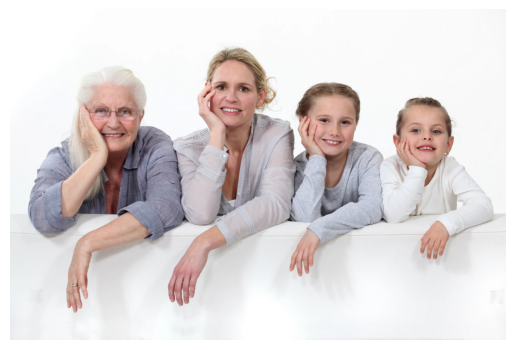

In [5]:
for imagePath in webpImages:
    if "girls" in imagePath.stem:
        with Image.open(imagePath) as image:
            plt.imshow(image)
    else:
        continue

plt.axis("off")